   Connected Devices  Network Latency (ms)  Packet Loss (%)  \
0               40.0                  20.2             1.04   
1              106.0                  79.6             4.53   
2               30.0                   NaN             2.23   
3               63.0                 123.3             3.20   
4                NaN                  27.0             3.30   

   Bandwidth Usage (%)  Access Point Load (%)  Signal Strength (dBm)  \
0                 79.3                   47.5                    -76   
1                206.4                   84.9                    -39   
2                 64.8                    NaN                    -47   
3                122.3                    NaN                    -56   
4                117.6                   51.9                    -81   

   Channel Utilization (%)  Retry Rate (%)  Congestion  
0                48.467361        1.212207           1  
1                57.915882        1.913272           1  
2                

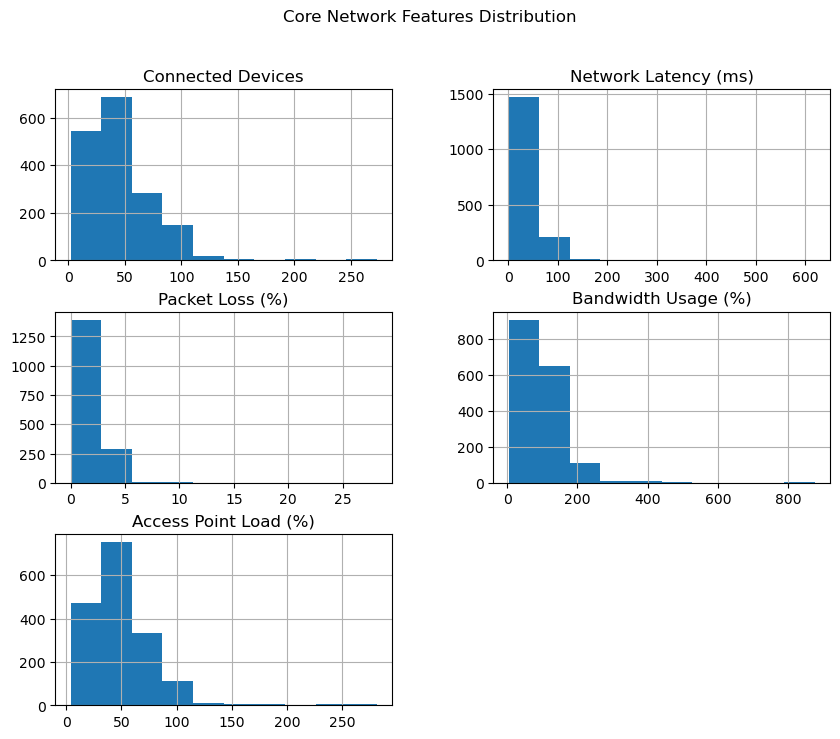

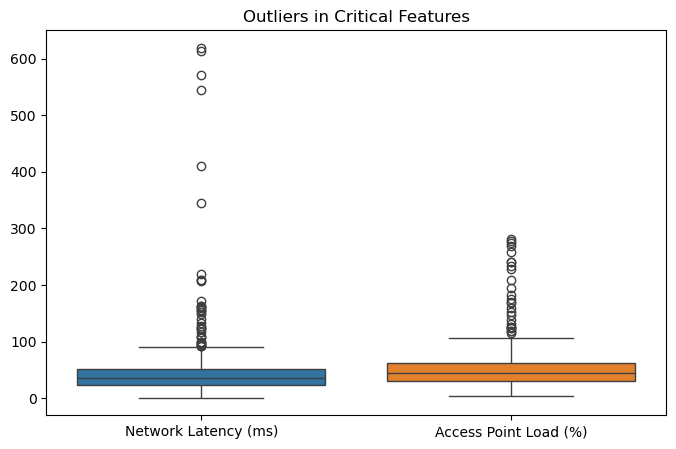

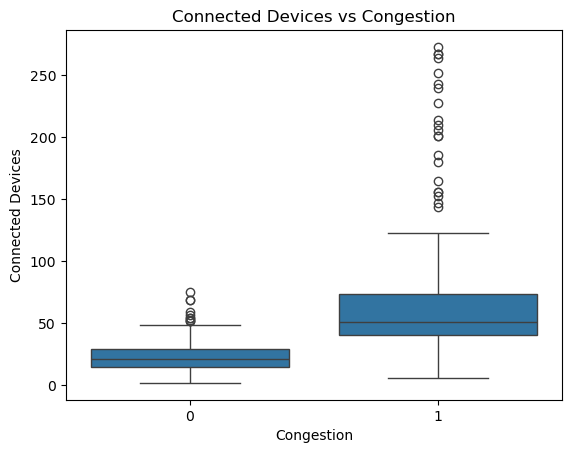

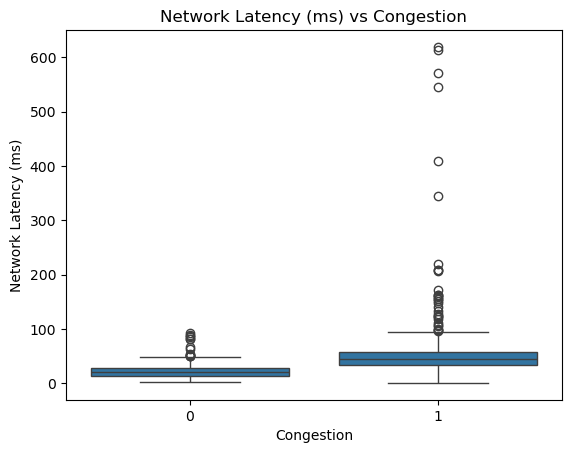

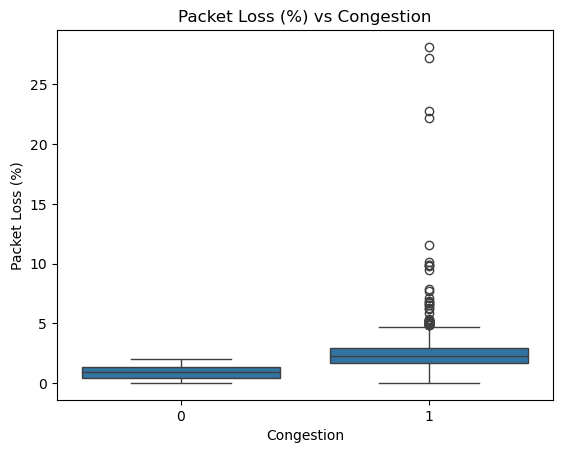

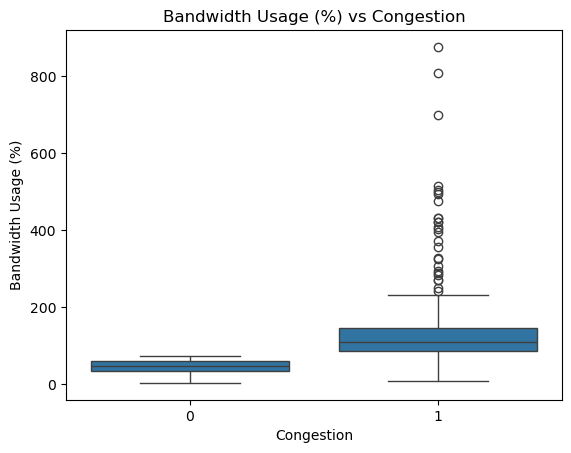

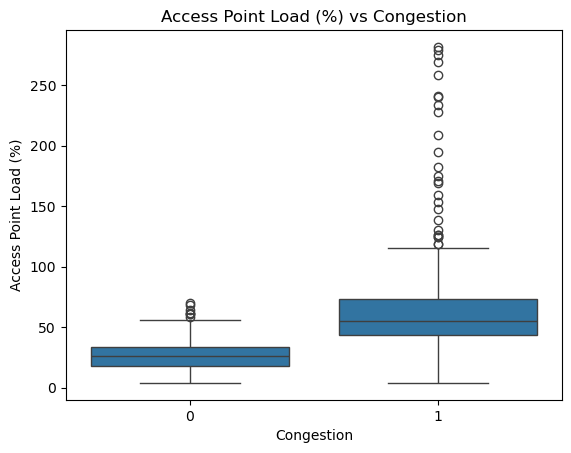

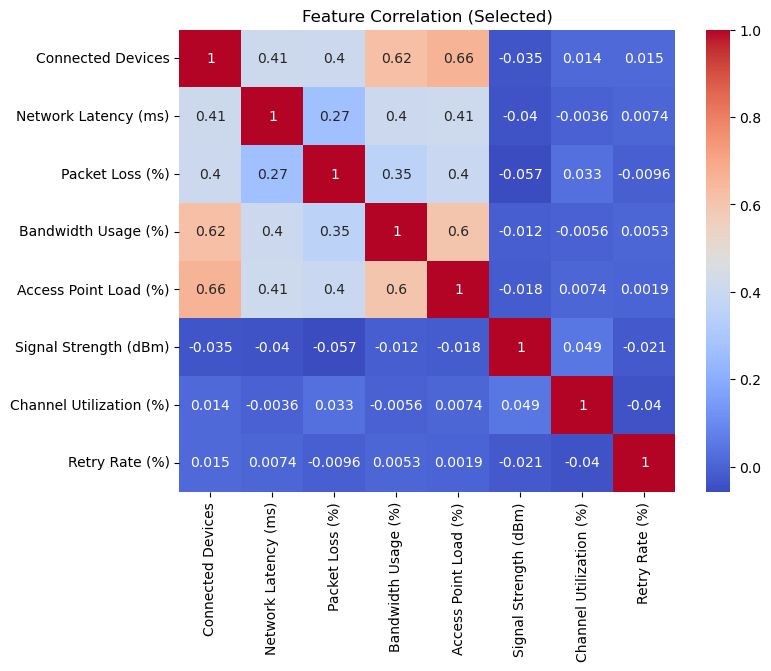

In [2]:
# =========================
# PHASE 1: EDA + DATA CLEANING
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Improved_WiFi_Dataset.csv")

# Basic info
print(df.head())
print(df.info())

# COLUMN GROUPING
network_core = [
    'Connected Devices',
    'Network Latency (ms)',
    'Packet Loss (%)',
    'Bandwidth Usage (%)',
    'Access Point Load (%)'
]

network_extra = [
    'Signal Strength (dBm)',
    'Channel Utilization (%)',
    'Retry Rate (%)'
]

target = 'Congestion'

# -------------------------
# EDA
# -------------------------

# Distribution
df[network_core].hist(figsize=(10,8))
plt.suptitle("Core Network Features Distribution")
plt.show()

# Outlier Detection
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['Network Latency (ms)', 'Access Point Load (%)']])
plt.title("Outliers in Critical Features")
plt.show()

# Congestion vs Features
for col in network_core:
    plt.figure()
    sns.boxplot(x=df[target], y=df[col])
    plt.title(f"{col} vs Congestion")
    plt.show()

# Correlation
plt.figure(figsize=(8,6))
corr = df[network_core + network_extra].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation (Selected)")
plt.show()

# -------------------------
# DATA CLEANING
# -------------------------

# Handle missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

# Outlier Treatment
def cap_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = np.clip(df[col], lower, upper)

cap_outliers('Network Latency (ms)')
cap_outliers('Packet Loss (%)')